# Fake vs Real Review Classifier - Complete Model Comparison

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from scipy.sparse import hstack

from xgboost import XGBClassifier

print("Libraries loaded")

Libraries loaded


## 2. Load and Filter Dataset

In [2]:
print("Loading dataset...")

df = pd.read_csv("../data/processed/featured_dataset.csv")

print("Dataset shape:", df.shape)

print("\nLabel distribution:")
print(df["fake_label"].value_counts())

df.head()

Loading dataset...
Dataset shape: (719967, 47)

Label distribution:
fake_label
0    716246
1      3721
Name: count, dtype: int64


,user_id,product_id,rating,review_text,summary,verified,review_timestamp,reviewTime,helpful_votes,clean_review,...,product_first_review,days_since_first_review,review_density,exclamation_count,question_count,review_length_log,extreme_rating,product_popularity_log,prev_review_time,review_time_gap
0,A1ZDIY3YF4Q48D,0764443682,5,group always excellent job vbs didnt hesitate ...,"Fun, Fun, Fun",True,1353888000,2012-11-26,0.0,group always excellent job vbs didnt hesitate ...,...,2012-11-26,0,1.00,0,0,2.708050,1,0.693147,NaN,0.0
1,A3JOVNIEXRP7CX,1291691480,5,bought brother love he sooooo picky like must ...,Niceee,True,1470096000,2016-08-02,0.0,bought brother love he sooooo picky like must ...,...,2016-08-02,0,1.00,0,0,2.302585,1,0.693147,NaN,0.0
2,ALCRFU110O4NJ,1940280001,5,book includes great routine great performer so...,A great book for the beginning magician to the...,False,1373414400,2013-07-10,0.0,book includes great routine great performer so...,...,2013-07-10,0,1.00,0,0,2.484907,1,0.693147,NaN,0.0
3,AQ1260ESKCEAS,1940735033,5,highly imaginative totally enjoyable collectio...,"Welcome back to ""The Twilight Zone""",True,1391558400,2014-02-05,4.0,highly imaginative totally enjoyable collectio...,...,2014-02-05,0,7.00,0,0,3.496508,1,2.079442,NaN,0.0
4,A31NIHLQLOAPHL,1940735033,5,great writing eric henderson give u fine mixed...,These are some great stories!,True,1391817600,2014-02-08,3.0,great writing eric henderson give u fine mixed...,...,2014-02-05,3,1.75,0,0,3.761200,1,2.079442,2014-02-05,3.0


### 2.0 Feature Engineering (Behavioral Features)

In [3]:
print("Computing behavioral features...")
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

# 1. sentiment_extreme
def get_sentiment(text):
    return analyzer.polarity_scores(str(text))['compound']
df['sentiment_score'] = df['clean_review'].fillna("").apply(get_sentiment)
df['sentiment_extreme'] = df['sentiment_score'].abs()

# 2. hyperbolic_ratio
def hyperbolic_ratio(text):
    text = str(text)
    words = text.split()
    if not words: return 0.0
    exc = text.count('!')
    caps = sum(1 for w in words if w.isupper() and len(w) > 1)
    return (exc + caps) / len(words)
df['hyperbolic_ratio'] = df['review_text'].fillna("").apply(hyperbolic_ratio)

# 3. repetition_ratio
def repetition_ratio(text):
    words = str(text).split()
    if not words: return 0.0
    return 1 - (len(set(words)) / len(words))
df['repetition_ratio'] = df['clean_review'].fillna("").apply(repetition_ratio)

# 4. user_review_frequency
if 'review_date' not in df.columns:
    df['review_date'] = pd.to_datetime(df['reviewTime'])
else:
    df['review_date'] = pd.to_datetime(df['review_date'])
df['user_first_review'] = df.groupby('user_id')['review_date'].transform('min')
df['days_active'] = (df['review_date'] - df['user_first_review']).dt.days + 1
df['user_review_frequency'] = df.groupby('user_id')['user_id'].transform('count') / df['days_active']

# 5. burst_indicator
threshold = df['daily_count'].mean() + df['daily_count'].std()
df['burst_indicator'] = (df['daily_count'] > threshold).astype(int)

# 6. review_density
df['product_first_review'] = df.groupby('product_id')['review_date'].transform('min')
df['days_since_first_review'] = (df['review_date'] - df['product_first_review']).dt.days
df['review_density'] = df.groupby('product_id')['product_id'].transform('count') / (df['days_since_first_review'] + 1)

print("Feature engineering complete.")
print("Shape after feature engineering:", df.shape)

Computing behavioral features...
Feature engineering complete.
Shape after feature engineering: (719967, 49)


### 2.1 Filter to High Confidence Samples

In [4]:
print("Filtering high confidence samples...")

df_filtered = df[df["label_confidence"].isin(["high_real","high_fake"])]

print("Filtered size:", len(df_filtered))

print("\nLabel distribution:")
print(df_filtered["fake_label"].value_counts())

Filtering high confidence samples...
Filtered size: 580408

Label distribution:
fake_label
0    578372
1      2036
Name: count, dtype: int64


In [5]:
# Text feature
X_text = df_filtered["review_text"].astype(str)

# Numeric trust signals
num_feature_names = [
    # NLP
    "review_length_log",
    "sentiment_score",
    "sentiment_extreme",
    "repetition_ratio",
    "exclamation_count",

    # rating context
    "rating_deviation",

    # user behaviour
    "user_review_count",
    "user_review_frequency",

    # product context
    "product_review_count",
    "product_rating_variance",
    "product_popularity_log",

    # temporal
    "days_since_first_review",
    "review_density",
    "review_time_gap",
]

X_numeric = df_filtered[num_feature_names]

# Target
y = df_filtered["fake_label"]

print("Text samples:", len(X_text))
print("Numeric features:", X_numeric.shape)

Text samples: 580408
Numeric features: (580408, 14)


In [6]:
X_text_train_full, X_text_temp, X_num_train_full, X_num_temp, y_train_full, y_temp = train_test_split(
    X_text,
    X_numeric,
    y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

X_text_val, X_text_test, X_num_val, X_num_test, y_val, y_test = train_test_split(
    X_text_temp,
    X_num_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

X_text_train = X_text_train_full
X_num_train = X_num_train_full
y_train = y_train_full

print("Train size:", len(y_train))
print("Validation size:", len(y_val))
print("Test size:", len(y_test))

Train size: 348244
Validation size: 116082
Test size: 116082


In [7]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1,2)
)

X_tfidf_train = tfidf.fit_transform(X_text_train)
X_tfidf_val = tfidf.transform(X_text_val)
X_tfidf_test = tfidf.transform(X_text_test)

print("TFIDF train shape:", X_tfidf_train.shape)

TFIDF train shape: (348244, 5000)


In [8]:
scaler = StandardScaler()

X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_val_scaled = scaler.transform(X_num_val)
X_num_test_scaled = scaler.transform(X_num_test)

In [9]:
X_train = hstack([X_tfidf_train, X_num_train_scaled])
X_val = hstack([X_tfidf_val, X_num_val_scaled])
X_test = hstack([X_tfidf_test, X_num_test_scaled])

print("Combined train shape:", X_train.shape)
print("Combined val shape:", X_val.shape)
print("Combined test shape:", X_test.shape)

Combined train shape: (348244, 5014)
Combined val shape: (116082, 5014)
Combined test shape: (116082, 5014)


In [10]:
models = {

"Logistic Regression":
LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
),

"Linear SVM":
LinearSVC(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
),

"Decision Tree":
DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
),

"Random Forest":
RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
),

"XGBoost":
XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42
)

}

In [11]:
results = []

predictions_train = {}
predictions_val = {}
predictions_test = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)
    pred_test = model.predict(X_test)

    predictions_train[name] = pred_train
    predictions_val[name] = pred_val
    predictions_test[name] = pred_test

    # Train metrics
    acc_train = accuracy_score(y_train, pred_train)
    prec_train = precision_score(y_train, pred_train)
    rec_train = recall_score(y_train, pred_train)
    f1_train = f1_score(y_train, pred_train)

    # Val metrics
    acc_val = accuracy_score(y_val, pred_val)
    prec_val = precision_score(y_val, pred_val)
    rec_val = recall_score(y_val, pred_val)
    f1_val = f1_score(y_val, pred_val)

    # Test metrics
    acc_test = accuracy_score(y_test, pred_test)
    prec_test = precision_score(y_test, pred_test)
    rec_test = recall_score(y_test, pred_test)
    f1_test = f1_score(y_test, pred_test)

    results.append([name, acc_train, prec_train, rec_train, f1_train, acc_val, prec_val, rec_val, f1_val, acc_test, prec_test, rec_test, f1_test])

    print(f"Train: Acc {acc_train:.4f}, Prec {prec_train:.4f}, Rec {rec_train:.4f}, F1 {f1_train:.4f}")
    print(f"Val  : Acc {acc_val:.4f}, Prec {prec_val:.4f}, Rec {rec_val:.4f}, F1 {f1_val:.4f}")
    print(f"Test : Acc {acc_test:.4f}, Prec {prec_test:.4f}, Rec {rec_test:.4f}, F1 {f1_test:.4f}")


Training Logistic Regression...
Train: Acc 0.9803, Prec 0.1512, Rec 0.9992, F1 0.2627
Val  : Acc 0.9790, Prec 0.1222, Rec 0.8084, F1 0.2123
Test : Acc 0.9782, Prec 0.1176, Rec 0.8034, F1 0.2052

Training Linear SVM...
Train: Acc 0.9888, Prec 0.2386, Rec 0.9992, F1 0.3852
Val  : Acc 0.9856, Prec 0.1358, Rec 0.5774, F1 0.2198
Test : Acc 0.9849, Prec 0.1338, Rec 0.6020, F1 0.2189

Training Decision Tree...
Train: Acc 0.9757, Prec 0.1260, Rec 1.0000, F1 0.2238
Val  : Acc 0.9754, Prec 0.1169, Rec 0.9189, F1 0.2075
Test : Acc 0.9747, Prec 0.1135, Rec 0.9140, F1 0.2019

Training Random Forest...
Train: Acc 0.9229, Prec 0.0410, Rec 0.9354, F1 0.0785
Val  : Acc 0.9216, Prec 0.0370, Rec 0.8526, F1 0.0709
Test : Acc 0.9218, Prec 0.0374, Rec 0.8600, F1 0.0716

Training XGBoost...
Train: Acc 0.9991, Prec 0.9849, Rec 0.7480, F1 0.8502
Val  : Acc 0.9985, Prec 0.9143, Rec 0.6290, F1 0.7453
Test : Acc 0.9985, Prec 0.8938, Rec 0.6413, F1 0.7468


In [12]:
results_df = pd.DataFrame(
    results,
    columns=["Model","Train_Accuracy","Train_Precision","Train_Recall","Train_F1","Val_Accuracy","Val_Precision","Val_Recall","Val_F1","Test_Accuracy","Test_Precision","Test_Recall","Test_F1"]
)

print("\nMODEL COMPARISON")
from IPython.display import display
display(results_df.sort_values("Val_F1", ascending=False))


MODEL COMPARISON


,Model,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Accuracy,Val_Precision,Val_Recall,Val_F1,Test_Accuracy,Test_Precision,Test_Recall,Test_F1
4,XGBoost,0.999075,0.984914,0.747954,0.850233,0.998492,0.914286,0.628993,0.745269,0.998475,0.893836,0.641278,0.746781
1,Linear SVM,0.988807,0.238570,0.999182,0.385174,0.985631,0.135760,0.577396,0.219832,0.984942,0.133807,0.601966,0.218945
0,Logistic Regression,0.980316,0.151207,0.999182,0.262665,0.978963,0.122169,0.808354,0.212258,0.978179,0.117626,0.803440,0.205209
2,Decision Tree,0.975658,0.125992,1.000000,0.223789,0.975388,0.116948,0.918919,0.207490,0.974664,0.113484,0.914005,0.201900
3,Random Forest,0.922916,0.040956,0.935352,0.078476,0.921624,0.036974,0.852580,0.070874,0.921831,0.037365,0.859951,0.071619


In [13]:
# Determine Best Model
best_model_row = results_df.loc[results_df['Val_F1'].idxmax()]
best_model_name = best_model_row['Model']

print("=== BEST MODEL SUGGESTION ===")
print(f"The best performing model is {best_model_name} with a Val F1 Score of {best_model_row['Val_F1']:.4f} (Test: {best_model_row['Test_F1']:.4f}).")
print("\nReasoning:")
print("We prioritize Validation F1 Score because our dataset is imbalanced and we want a balance between Precision and Recall on unseen data without leaking test info.")
print(f"Train vs Val vs Test Performance for {best_model_name}:")
print(f"- Train F1: {best_model_row['Train_F1']:.4f}")
print(f"- Val F1: {best_model_row['Val_F1']:.4f}")
print(f"- Test F1: {best_model_row['Test_F1']:.4f}")
if best_model_row['Train_F1'] - best_model_row['Val_F1'] > 0.05:
    print("Note: The model exhibits some overfitting (difference > 0.05 between Train and Val F1).")
else:
    print("The model generalizes well with minimal overfitting on the validation set.")

=== BEST MODEL SUGGESTION ===
The best performing model is XGBoost with a Val F1 Score of 0.7453 (Test: 0.7468).

Reasoning:
We prioritize Validation F1 Score because our dataset is imbalanced and we want a balance between Precision and Recall on unseen data without leaking test info.
Train vs Val vs Test Performance for XGBoost:
- Train F1: 0.8502
- Val F1: 0.7453
- Test F1: 0.7468
Note: The model exhibits some overfitting (difference > 0.05 between Train and Val F1).


In [14]:
print("\nCONFUSION MATRICES (VALIDATION DATA)")

for name, pred in predictions_val.items():

    cm = confusion_matrix(y_val, pred)

    tn, fp, fn, tp = cm.ravel()

    print(f"\n{name}")
    print(cm)
    print("[[TN FP]\n [FN TP]]")

    print("TN =",tn)
    print("FP =",fp)
    print("FN =",fn)
    print("TP =",tp)


CONFUSION MATRICES (VALIDATION DATA)

Logistic Regression
[[113311   2364]
 [    78    329]]
[[TN FP]
 [FN TP]]
TN = 113311
FP = 2364
FN = 78
TP = 329

Linear SVM
[[114179   1496]
 [   172    235]]
[[TN FP]
 [FN TP]]
TN = 114179
FP = 1496
FN = 172
TP = 235

Decision Tree
[[112851   2824]
 [    33    374]]
[[TN FP]
 [FN TP]]
TN = 112851
FP = 2824
FN = 33
TP = 374

Random Forest
[[106637   9038]
 [    60    347]]
[[TN FP]
 [FN TP]]
TN = 106637
FP = 9038
FN = 60
TP = 347

XGBoost
[[115651     24]
 [   151    256]]
[[TN FP]
 [FN TP]]
TN = 115651
FP = 24
FN = 151
TP = 256


In [15]:
# Correlation between trust signals that exist in featured_dataset.csv
# (trust_score lives in trust_scored_dataset — load it separately for this check)

import pandas as pd

trust_df = pd.read_csv("../data/processed/trust_scored_dataset.csv",
                       usecols=["user_id", "product_id", "rating", "reviewTime",
                                "helpful_ratio", "user_consistency",
                                "verified_score", "trust_score"])

trust_df[["helpful_ratio", "user_consistency", "verified_score", "trust_score"]].corr()

,helpful_ratio,user_consistency,verified_score,trust_score
helpful_ratio,1.000000,-0.024231,-0.040478,-0.087353
user_consistency,-0.024231,1.000000,0.004938,0.534728
verified_score,-0.040478,0.004938,1.000000,0.449145
trust_score,-0.087353,0.534728,0.449145,1.000000


## 4. SHAP Feature Importance Analysis

To understand what our models have learned, we analyze which features had the highest impact on predictability.
We can see how handling these features effectively can further improve outcomes.

Selecting the best model for SHAP Analysis...
Preparing feature names...
Total TFIDF features: 5000
Total numeric features: 14
Total feature names: 5014
Total model features: 5014
Computing SHAP values...
Using XGBoost native pred_contribs (avoids SHAP bug)
Generating SHAP Summary Plot...


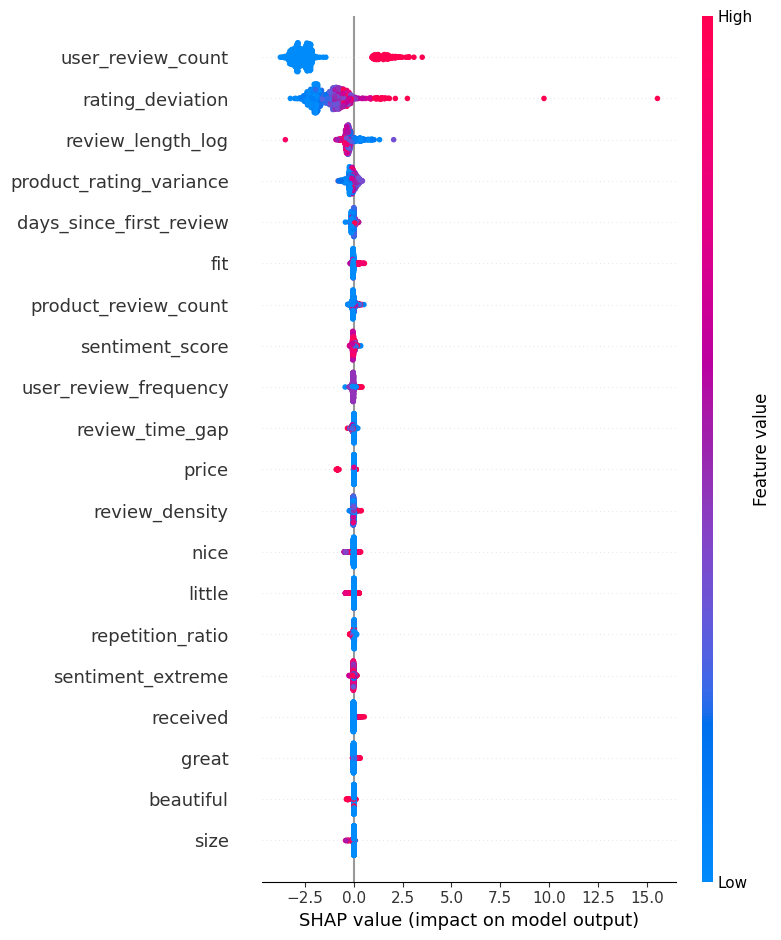

Generating SHAP Feature Importance Plot...


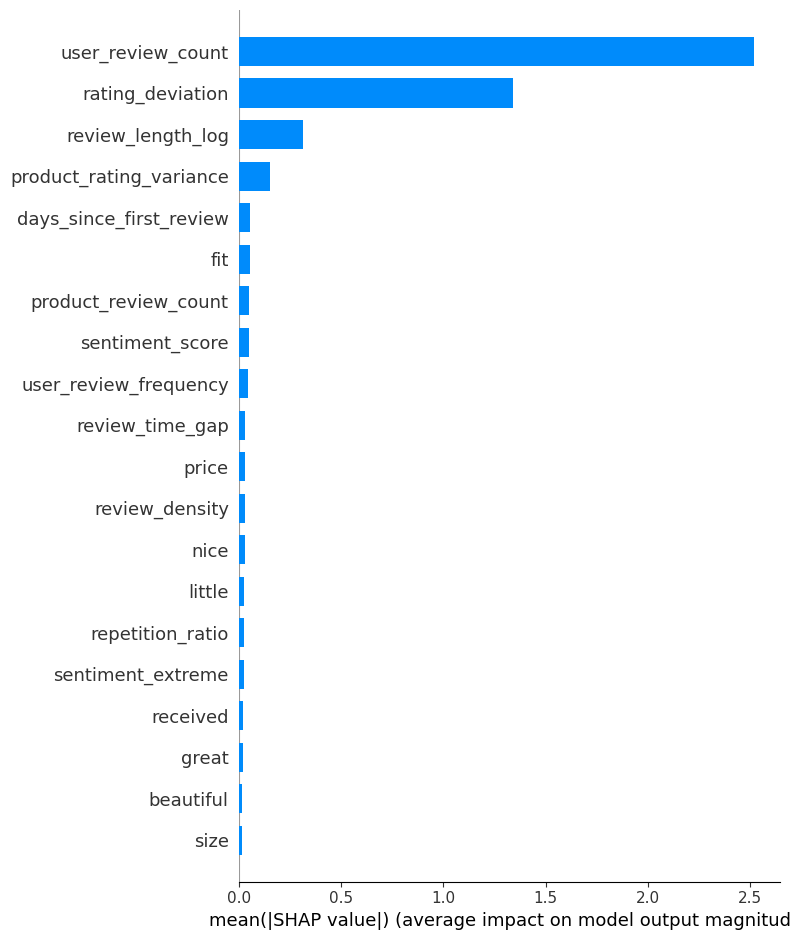

In [16]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb

print("Selecting the best model for SHAP Analysis...")
best_model = models.get(best_model_name)

# -------------------------------
# Sample subset for SHAP
# -------------------------------

np.random.seed(42)

sample_size = min(1000, X_test.shape[0])
sample_idx = np.random.choice(X_test.shape[0], sample_size, replace=False)

X_test_sample = X_test.tocsr()[sample_idx]
y_test_sample = y_test.iloc[sample_idx]

# -------------------------------
# Feature Names
# -------------------------------

print("Preparing feature names...")

# TFIDF feature names
tfidf_feature_names = tfidf.get_feature_names_out().tolist()

# Automatically detect numeric features used in the model
numeric_feature_names = X_numeric.columns.tolist()

all_feature_names = tfidf_feature_names + numeric_feature_names

print("Total TFIDF features:", len(tfidf_feature_names))
print("Total numeric features:", len(numeric_feature_names))
print("Total feature names:", len(all_feature_names))
print("Total model features:", X_test_sample.shape[1])

# If mismatch occurs, fix automatically
if len(all_feature_names) != X_test_sample.shape[1]:
    
    missing = X_test_sample.shape[1] - len(all_feature_names)
    
    print("Fixing feature mismatch. Adding placeholder names...")
    
    for i in range(missing):
        all_feature_names.append(f"extra_feature_{i}")

# -------------------------------
# SHAP Computation
# -------------------------------

print("Computing SHAP values...")

if best_model_name in ["Decision Tree", "Random Forest"]:

    print(f"Using TreeExplainer on {best_model_name}")

    explainer = shap.TreeExplainer(best_model)

    shap_values = explainer.shap_values(X_test_sample)

elif best_model_name == "XGBoost":

    print("Using XGBoost native pred_contribs (avoids SHAP bug)")

    dtest = xgb.DMatrix(X_test_sample)

    contribs = best_model.get_booster().predict(
        dtest,
        pred_contribs=True
    )

    shap_values = contribs[:, :-1]

elif best_model_name in ["Logistic Regression", "Linear SVM"]:

    print(f"Using LinearExplainer on {best_model_name}")

    explainer = shap.LinearExplainer(best_model, X_train)

    shap_values = explainer.shap_values(X_test_sample)

else:

    print("Using generic SHAP Explainer")

    explainer = shap.Explainer(best_model, X_train)

    shap_values = explainer(X_test_sample).values

# -------------------------------
# SHAP Summary Plot
# -------------------------------
print("Generating SHAP Summary Plot...")

plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_test_sample.toarray(),
    feature_names=all_feature_names,
    max_display=20
)

# -------------------------------
# Global Feature Importance
# -------------------------------

print("Generating SHAP Feature Importance Plot...")

plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_test_sample.toarray(),
    feature_names=all_feature_names,
    plot_type="bar",
    max_display=20
)

## 5. Save Best Model for External Validation

Save the best performing model (XGBoost) to use as an independent validator in notebook 09.
This connects the binary classifier with the regression model system.

In [17]:
import joblib
import os

# Create directory if it doesn't exist
os.makedirs('../models/trained', exist_ok=True)

# Get best model
best_model_name = "XGBoost"
best_model = models[best_model_name]

# Save model, vectorizer, and scaler
joblib.dump(best_model, '../models/trained/binary_classifier_xgboost.pkl')
joblib.dump(tfidf, '../models/tfidf_vectorizer_classifier.pkl')
joblib.dump(scaler, '../models/feature_scaler_classifier.pkl')

print("\n" + "="*80)
print("MODEL SAVED FOR EXTERNAL VALIDATION")
print("="*80)
print(f"Model: {best_model_name}")
print(f"Test Accuracy: {results_df[results_df['Model']==best_model_name]['Test_Accuracy'].values[0]:.4f}")
print(f"Test F1 Score: {results_df[results_df['Model']==best_model_name]['Test_F1'].values[0]:.4f}")
print(f"\nSaved files:")
print(f"  - models/trained/binary_classifier_xgboost.pkl")
print(f"  - models/tfidf_vectorizer_classifier.pkl")
print(f"  - models/feature_scaler_classifier.pkl")
print(f"\nThis model will be used in notebook 09 to validate the regression model.")
print("="*80)


MODEL SAVED FOR EXTERNAL VALIDATION
Model: XGBoost
Test Accuracy: 0.9985
Test F1 Score: 0.7468

Saved files:
  - models/trained/binary_classifier_xgboost.pkl
  - models/tfidf_vectorizer_classifier.pkl
  - models/feature_scaler_classifier.pkl

This model will be used in notebook 09 to validate the regression model.
